# Comparing populations with samples

**The research question.** Two concert pianists both have Chopin's Ballade No. 1 in
their repertoire. Does **Pianist A** take the piece slower than **Pianist B**?

No two performances of the Ballade last exactly the same: tempo choices, rubato, the
hall, the mood of the evening all move the duration around by tens of seconds. The
"population" we care about is *every performance each pianist could ever give*. But we can never actually observe them all. We can only time a **sample**: the few recordings and concerts we
have access to.

This notebook simulates a world in which **we secretly know the truth about every possible
performance from the two pianists.** Then, we impersonate a researcher who does *not* know the
truth, and tries to compare samples.

In [1]:
# ═══ SETUP ═══  libraries, the master seed, and a consistent look for all plots
import numpy as np
import matplotlib.pyplot as plt

# One random generator for the whole simulated world
rng = np.random.default_rng(26)   # ← knob: change the seed for a different run of luck

BLUE, ORANGE = "#2a78d6", "#eb6834"   # Pianist A / Pianist B
INK, MUTED   = "#0b0b0b", "#898781"
SURFACE      = "#fcfcfb"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "font.size": 11, "figure.dpi": 110,
})

### How this notebook is organised

The code below is split into two kinds of cells, marked by a banner in
the first line:

- **`═══ DATA GENERATION ═══`** cells build the simulated world: they set the true
  distributions, draw the samples, and run the repeated studies.
- **`═══ PLOTTING ONLY ═══`** cells just *look at* data that already exists. They never
  create or change anything, and they adapt automatically to whatever the generation
  cells produced. Some of these plotting cells are interactive:
  **`═══ INTERACTIVE PLOT ═══`**.

In the generation cells, every line tagged
`# ← knob` is a parameter that you can change: true means, spreads, sample sizes.

1. edit a knob in a generation cell,
2. re-run that cell (Shift + Enter) **and everything below it**, so all downstream analyses see the new simulated world.

## 1. What does it mean to "sample from a distribution"?


**Some quantities are not single numbers.** *How many keys does a modern piano have?*
88. This is a plain number, the same every time. Now: *how long does Pianist X's
performance of Chopin's First Ballade last?* There is no single answer to this question. It was 9:02
last month, 8:51 tonight, and next week it will be something else again. The quantity
"duration of a performance" does not *have* a value — it takes a **different value each
time the process happens**. Quantities of this kind are called **random variables**
(NB: "random", here, does not mean arbitrary or lawless)

**A random variable is described by its distribution.** Since no single number can
represent a random variable, we describe random variables by saying which values are possible and how often each
tends to occur. This description is called a **distribution**. For our pianist's performance durations
it is a bell-shaped curve centred on 540 seconds: durations near 9 minutes are common
(the curve is high there), durations of 8 or 10 minutes are rare (the curve is low
there). The answer to the question "how long does a performance take" is not a single number, but rather the shape of the distribution.

**Sampling** — or *drawing* — from the distribution means asking chance to select **one
concrete value of the random variable**, with the odds weighted by the curve: values
under the high part come up often, values under the low tails come up rarely. One draw
is one performance that could actually happen (as if you were to sit at the piano on a random day and start playing).

In [3]:
# ═══ DATA GENERATION ═══  the demo's random variable
demo_rng = np.random.default_rng(11)   # side generator: demo only, main world untouched

demo_mean = 540   # ← knob: centre of the distribution (seconds)
demo_sd   = 30    # ← knob: spread — how much one draw can differ from the centre

draws = [demo_rng.normal(demo_mean, demo_sd)]   # the first draw; buttons below add more

Try it yourself. Run the cell below, then:

- click **“draw 1 value”** a few times.  Each draw lands somewhere new, usually near
  the middle, occasionally out in a tail. The orange dot marks the latest draw;
- then click **“draw 100 values”** a few times. Watch the pile of draws grow into
  the shape of the dashed curve.

In [ ]:
# ═══ INTERACTIVE PLOT ═══  (the buttons append new draws to `draws` via demo_rng)
import ipywidgets as widgets

draw1_button   = widgets.Button(description="🎲  draw 1 value",
                                layout=widgets.Layout(width="150px"))
draw100_button = widgets.Button(description="🎲  draw 100 values",
                                layout=widgets.Layout(width="160px"))
demo_panel = widgets.Output()

def redraw_demo():
    k, bin_width = len(draws), 10
    x_curve = np.linspace(demo_mean - 4 * demo_sd, demo_mean + 4 * demo_sd, 300)
    pdf = (np.exp(-0.5 * ((x_curve - demo_mean) / demo_sd) ** 2)
           / (demo_sd * np.sqrt(2 * np.pi)))
    with demo_panel:
        demo_panel.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 3.4))
        ax.hist(draws, bins=np.arange(x_curve[0], x_curve[-1], bin_width), color=BLUE,
                edgecolor=SURFACE, linewidth=0.8, label="draws so far")
        ax.plot(x_curve, pdf * k * bin_width, color=INK, linewidth=1.4,
                linestyle="--", label="the distribution (long-run shape)")
        ax.plot(draws[-1], 0, "o", color=ORANGE, markersize=9, clip_on=False,
                markeredgecolor=SURFACE, markeredgewidth=1)
        ax.set_xlabel("performance duration (s)")
        ax.set_ylabel("number of draws")
        ax.set_title(f"{k} draw{'s' if k > 1 else ''} from the distribution — "
                     f"latest: {draws[-1]:.0f} s")
        ax.legend(frameon=False)
        plt.show()
        plt.close(fig)   # tidy up: callback figures aren't closed automatically

def add_draws(m):
    draws.extend(demo_rng.normal(demo_mean, demo_sd, size=m))
    redraw_demo()

draw1_button.on_click(lambda _: add_draws(1))
draw100_button.on_click(lambda _: add_draws(100))
display(widgets.VBox([widgets.HBox([draw1_button, draw100_button]), demo_panel]))
redraw_demo()

Three lessons to take from the demo:

- **The distribution is the limit of what the process looks like when it is repeated (infinitely) many times; any finite set of draws is
  a noisy glimpse of it.** After 5 draws the histogram looks nothing like the curve;
  after 1,000 it is very much similar.
- In a real study you never get to see the dashed curve, **you only see the
  draws.** 
- **This is what "quantitative" really means in research.** Almost every quantity we
  study (performance durations, listeners' ratings, number of correct notes
 in a sight-reading test, reaction times) is a random variable, not a fixed
  number. So the data we collect are never "the value" of anything: **a dataset is a
  sample of draws** from some population that we cannot fully observe. A research question like *"does Pianist A take the piece
  slower than Pianist B?"* is really a question about two invisible distributions —
  *"is the centre of A's distribution higher than the centre of B's?"*. The difficulty is that we need to answer this question by looking at  must be answered from draws alone.

Everything that follows does nothing else: we build a simulated world by fixing the distribution of some random variables, we sample from them, and see how much or how little the
samples reveal about the underlying distributions. 

## 2. Warm-up: even measuring *one* number is not trivial

Before comparing two pianists performing Chopin, let's do something much simpler: measuring a single quantity.

Twelve students are asked to time **the same studio recording** of the Ballade, each
with a stopwatch. In our simulated world we know the exact truth: the recording lasts
**540.0 seconds** (9 minutes). But every stopwatch reading is contaminated by
*measurement error*: reaction time at the start, reaction time at the end, a moment
of distraction, different understandings of what counts as a "start" and an "end". 

We simulate each student's reading as

$$\text{measurement} = \text{truth} + \text{error}$$

with errors of a bit over half a second either way.

In [14]:
# ═══ DATA GENERATION ═══  twelve stopwatch readings of one fixed recording
true_duration = 540.0   # ← knob: the recording's real length (only we know this)
STOPWATCH_SD  = .6     # ← knob: typical size of the error, in seconds
n_students    = 12      # ← knob: how many students time the recording

measurements = true_duration + rng.normal(loc=0, scale=STOPWATCH_SD, size=n_students)

print(f"The {n_students} stopwatch readings (seconds):")
print("  " + "  ".join(f"{m:.1f}" for m in measurements))
print(f"\nTruth:                    {true_duration:.2f} s")
print(f"Mean of the measurements: {measurements.mean():.2f} s")
print(f"Worst single measurement is off by {np.abs(measurements - true_duration).max():.2f} s;")
print(f"the mean is off by only {abs(measurements.mean() - true_duration):.2f} s")

The 12 stopwatch readings (seconds):
  539.3  540.0  540.7  540.5  539.4  540.5  539.5  539.0  540.2  540.4  540.9  539.5

Truth:                    540.00 s
Mean of the measurements: 540.00 s
Worst single measurement is off by 0.98 s;
the mean is off by only 0.00 s


**Collect the readings one at a time.** Run the next cell, then click
**“time the recording again”**: first you reveal the readings from above, one per
click; after that, every click produces a fresh reading. Watch the orange line — single
readings jump around, but the mean settles onto the truth.

In [15]:
# ═══ INTERACTIVE PLOT ═══  (reveals the readings above; extra clicks use a side generator)
readings = list(measurements)
extra_stopwatch = np.random.default_rng(7)   # side generator: main world untouched

shown = {"k": 1}
timer_button = widgets.Button(description="⏱  time the recording again",
                              layout=widgets.Layout(width="240px"))
timer_panel = widgets.Output()

def redraw_stopwatch():
    k = shown["k"]
    vals = np.array(readings[:k])
    with timer_panel:
        timer_panel.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 3.4))
        ax.plot(np.arange(1, k + 1), vals, "o", color=BLUE, markersize=8,
                markeredgecolor=SURFACE, markeredgewidth=1)
        ax.axhline(true_duration, color=INK, linewidth=1.2, linestyle="--")
        ax.axhline(vals.mean(), color=ORANGE, linewidth=2)
        right = max(13, k + 1)
        ax.annotate(f"truth: {true_duration:.1f} s", (right + 0.3, true_duration),
                    va="bottom", fontsize=10, color=INK,
                    xytext=(0, 5), textcoords="offset points")
        ax.annotate(f"mean: {vals.mean():.2f} s", (right + 0.3, vals.mean()),
                    va="top", fontsize=10, color=ORANGE,
                    xytext=(0, -5), textcoords="offset points")
        ax.set_xlim(0.3, right + 3.5)
        ax.set_ylim(true_duration - 4 * STOPWATCH_SD, true_duration + 4 * STOPWATCH_SD)
        ax.set_xlabel("measurement number")
        ax.set_ylabel("measured duration (s)")
        ax.set_title(f"{k} measurement{'s' if k > 1 else ''} of the same recording — "
                     f"mean is off by {abs(vals.mean() - true_duration):.2f} s")
        plt.show()
        plt.close(fig)   # tidy up: callback figures aren't closed automatically

def add_reading(_):
    shown["k"] += 1
    if shown["k"] > len(readings):                       # past the scripted readings:
        readings.append(true_duration + extra_stopwatch.normal(0, STOPWATCH_SD))
    redraw_stopwatch()

timer_button.on_click(add_reading)
display(widgets.VBox([timer_button, timer_panel]))
redraw_stopwatch()

Three things to notice:

1. **No measurement equals the truth.** Every reading = truth + error.
2. **The errors scatter in both directions**, so they partly cancel: the **mean** of
   the twelve readings is much closer to the truth than a typical single reading.
3. If the class repeated the whole exercise tomorrow, they would get twelve *new*
   readings and a *new* mean: close to 540.0 again, but not identical. **The mean
   itself is a measurement, and it too has an error** (just a smaller one).


## 3. Two performers who are *exactly* identical

First, we create a simulated world. We give each pianist a whole imagined career:
**10,000 performances** of the Ballade each, each one with its own duration.
Crucially, both pianists draw from **the same distribution**: on average 540 seconds,
with performances varying night to night by a standard deviation of 30 seconds.

So in this simulated world the true answer to our research question is:
**there is no difference at all between the pianists.** However, the
researcher doesn't know it.

In [22]:
# ═══ DATA GENERATION ═══  the two populations: every performance of each pianist
N_POP   = 10_000   # ← knob: number of performances per pianist (all those that happened and those that could have happened)
PERF_SD = 30       # ← knob: spread of a pianist's performance durations (seconds)
MEAN_A  = 540      # ← knob: Pianist A's true mean duration (seconds)
MEAN_B  = 540      # ← knob: Pianist B's — equal to A on purpose

def make_performer(mean_seconds):
    """All the durations (in seconds) of one pianist's possible performances."""
    return rng.normal(loc=mean_seconds, scale=PERF_SD, size=N_POP)

pianist_A = make_performer(MEAN_A)
pianist_B = make_performer(MEAN_B)

print(f"Mean duration, Pianist A: {pianist_A.mean():6.1f} s")
print(f"Mean duration, Pianist B: {pianist_B.mean():6.1f} s")
print(f"Population-level difference:               {pianist_A.mean() - pianist_B.mean():6.1f} s")

Mean duration, Pianist A:  540.0 s
Mean duration, Pianist B:  540.0 s
Population-level difference:                  0.0 s


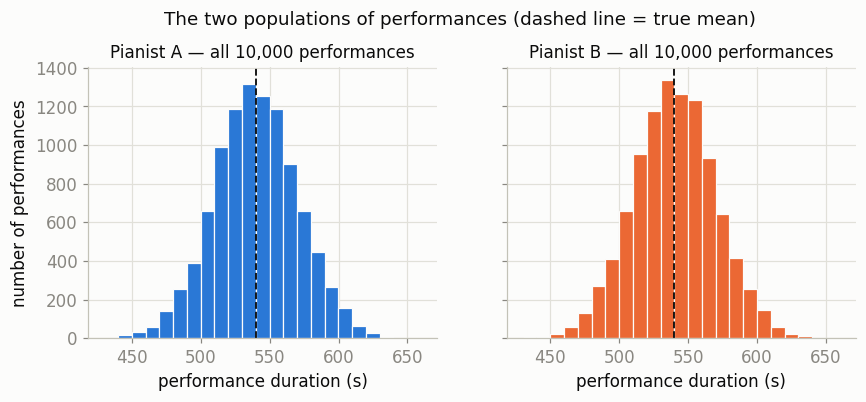

In [23]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharex=True, sharey=True)
lo = min(pianist_A.min(), pianist_B.min())
hi = max(pianist_A.max(), pianist_B.max())
bins = np.arange(lo, hi + 10, 10)    # 10-second bins covering all the data

for ax, perf, name, color in [(axes[0], pianist_A, "Pianist A", BLUE),
                              (axes[1], pianist_B, "Pianist B", ORANGE)]:
    ax.hist(perf, bins=bins, color=color, edgecolor=SURFACE, linewidth=0.8)
    ax.axvline(perf.mean(), color=INK, linewidth=1.2, linestyle="--")
    ax.set_title(f"{name} — all {len(perf):,} performances", fontsize=11)
    ax.set_xlabel("performance duration (s)")

axes[0].set_ylabel("number of performances")
fig.suptitle("The two populations of performances (dashed line = true mean)",
             y=1.04, fontsize=12)
plt.show()

The two histograms are, for all practical purposes, the same picture. Of course:
the simulated world is built this way. Now let's forget we know this.

## 4. One study: time 15 performances of each pianist

A real researcher cannot see the histograms above. They collect what they can get hold
of (say **15 randomly chosen performances of each pianist**) and time them. That's one *study*: one sample for panist A and one sample for pianist B. Let's run it.

In [24]:
# ═══ DATA GENERATION ═══  one study: two samples of performances
n = 15   # ← knob: number of performances timed per pianist

sample_A = rng.choice(pianist_A, size=n, replace=False)
sample_B = rng.choice(pianist_B, size=n, replace=False)

diff_observed = sample_A.mean() - sample_B.mean()

print(f"Sample mean, Pianist A ({n} performances): {sample_A.mean():6.1f} s")
print(f"Sample mean, Pianist B ({n} performances): {sample_B.mean():6.1f} s")
print(f"Observed difference:                       {diff_observed:+6.1f} s")

Sample mean, Pianist A (15 performances):  536.6 s
Sample mean, Pianist B (15 performances):  532.0 s
Observed difference:                         +4.6 s


**Now watch the study unfold performance by performance.** Run the next cell and
click **“time +1 performance of each”**. The black bars are the running sample means —
see how they wander as each new timing arrives, and where they happen to stop when your
supply of recordings runs out.

In [25]:
# ═══ INTERACTIVE PLOT ═══  (reveals the two samples above one timing at a time)
jitter_A = rng.uniform(-0.08, 0.08, size=n)   # spread the dots out a little
jitter_B = rng.uniform(-0.08, 0.08, size=n)

surveyed = {"k": 1}
survey_button = widgets.Button(description="🎹  time +1 performance of each",
                               layout=widgets.Layout(width="260px"))
survey_panel = widgets.Output()

def redraw_study():
    k = surveyed["k"]
    with survey_panel:
        survey_panel.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(7, 3.6))
        for x, sample, jitter, color in [(0, sample_A, jitter_A, BLUE),
                                         (1, sample_B, jitter_B, ORANGE)]:
            ax.plot(x + jitter[:k], sample[:k], "o", color=color, markersize=7,
                    markeredgecolor=SURFACE, markeredgewidth=1, alpha=0.9)
            ax.hlines(sample[:k].mean(), x - 0.18, x + 0.18, color=INK, linewidth=2)
            ax.annotate(f"mean {sample[:k].mean():.0f} s", (x + 0.22, sample[:k].mean()),
                        va="center", fontsize=10, color=INK)
        ax.set_xticks([0, 1], ["Pianist A", "Pianist B"])
        ax.set_xlim(-0.6, 1.8)
        ax.set_ylim(min(sample_A.min(), sample_B.min()) - 10,
                    max(sample_A.max(), sample_B.max()) + 10)
        ax.set_ylabel("performance duration (s)")
        diff_so_far = sample_A[:k].mean() - sample_B[:k].mean()
        ax.set_title(f"{k} of {n} performances timed per pianist — "
                     f"difference so far: {diff_so_far:+.1f} s")
        plt.show()
        plt.close(fig)   # tidy up: callback figures aren't closed automatically

def add_student(_):
    surveyed["k"] = min(surveyed["k"] + 1, n)
    if surveyed["k"] == n:
        survey_button.disabled = True
        survey_button.description = f"study complete (n = {n})"
    redraw_study()

survey_button.on_click(add_student)
display(widgets.VBox([survey_button, survey_panel]))
redraw_study()

**The samples differ!** A music journalist could already write the headline:

> *"Study finds Pianist A takes the Ballade markedly slower than Pianist B."*

But *we* know the two pianists are identical (we created them identical). The difference above is produced by
**sampling luck** alone: which 15 performances out of all those that the two pianists could have produced happened to end up in our hands.

This is the core problem: **a difference between samples is not evidence, by itself,
of a difference between populations.** So how big does a difference have to be before
we take it seriously? To answer that, let's do something no real researcher can do:
repeat the entire study a thousand times.

## 5. Repeat the study 1,000 times

Same world (identical pianists), same method (15 performances of each). Each repetition
gives one "observed difference". We collect all 1,000 of them.

In [30]:
# ═══ DATA GENERATION ═══  1,000 repetitions of the whole study
def one_study(pop_1, pop_2, n):
    """Time n performances from each population; return the difference in sample means."""
    s1 = rng.choice(pop_1, size=n, replace=False)
    s2 = rng.choice(pop_2, size=n, replace=False)
    return s1.mean() - s2.mean()

n_studies = 1_000   # ← knob: how many times the study is repeated

diffs = np.array([one_study(pianist_A, pianist_B, n) for _ in range(n_studies)])

as_large = np.mean(np.abs(diffs) >= abs(diff_observed)) * 100
print(f"Largest difference found by pure chance: {np.abs(diffs).max():.1f} s")
print(f"Studies with a difference at least as large as ours ({abs(diff_observed):.1f} s): "
      f"{as_large:.0f}%")

Largest difference found by pure chance: 35.9 s
Studies with a difference at least as large as ours (4.6 s): 67%


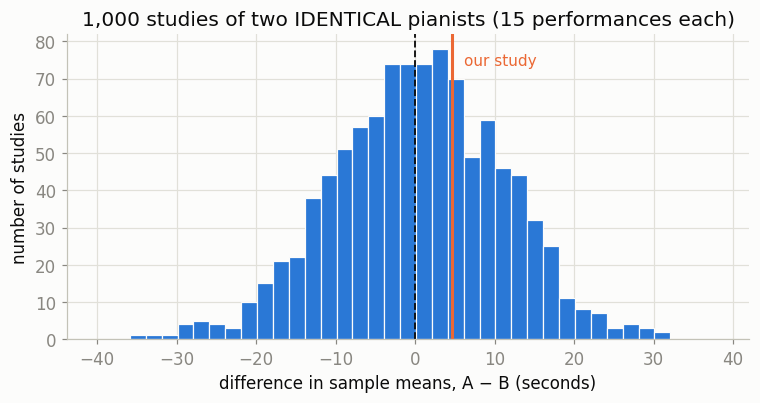

In [31]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, ax = plt.subplots(figsize=(8, 3.6))

span = np.abs(diffs).max() + 4
ax.hist(diffs, bins=np.arange(-span, span, 2), color=BLUE,
        edgecolor=SURFACE, linewidth=0.8)
ax.axvline(0, color=INK, linewidth=1.2, linestyle="--")
ax.axvline(diff_observed, color=ORANGE, linewidth=2)
ax.annotate("our study", (diff_observed, ax.get_ylim()[1] * 0.9),
            color=ORANGE, fontsize=10,
            ha="left" if diff_observed >= 0 else "right",
            xytext=(8 if diff_observed >= 0 else -8, 0), textcoords="offset points")

ax.set_xlabel("difference in sample means, A − B (seconds)")
ax.set_ylabel("number of studies")
ax.set_title(f"{n_studies:,} studies of two IDENTICAL pianists ({n} performances each)")
plt.show()

Every one of those 1,000 differences is pure chance — the true difference is zero.
And yet single studies routinely "find" differences of ten, twenty, even thirty seconds.

This histogram shows **what chance
alone can produce** when there is no difference in reality. This is called the "null" distribution. Judging a study result means asking: **where does it fall on this
histogram?** A result that is very likely to happen by chance does not allow us to conclude that there is a difference between the two random variable; a result far
out in the tails is *surprising* if there is no real difference between the random variables: this is when we might start believing that there actually is a difference.

## 6. Bigger samples
Chance never disappears, but it shrinks as samples grow. Same experiment — 1,000
studies of the two identical pianists with increasing sample sizes. 

In [32]:
# ═══ DATA GENERATION ═══  the same 1,000 studies, at several sample sizes
sample_sizes = [10, 50, 200, 1000]   # ← knob: try other sizes (max: N_POP)

diffs_by_size = {size: np.array([one_study(pianist_A, pianist_B, size)
                                 for _ in range(n_studies)])
                 for size in sample_sizes}

for size in sample_sizes:
    print(f"n = {size:4d}:  chance differences span "
          f"±{np.abs(diffs_by_size[size]).max():5.1f} s")

n =   10:  chance differences span ± 44.4 s
n =   50:  chance differences span ± 21.7 s
n =  200:  chance differences span ± 10.1 s
n = 1000:  chance differences span ±  4.9 s


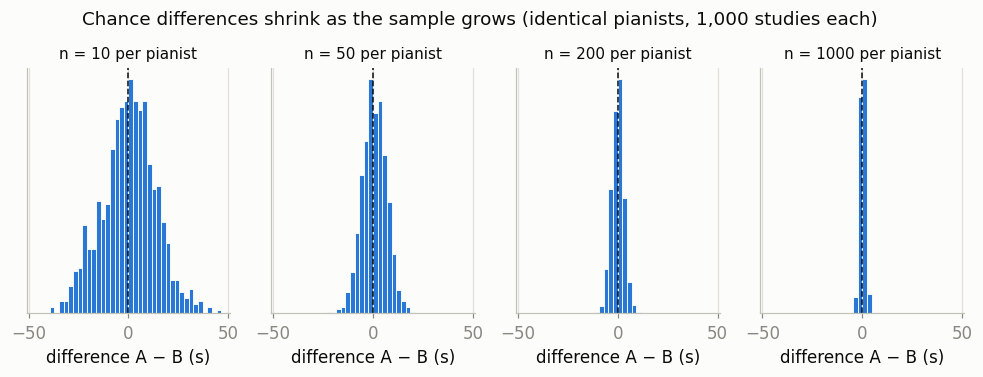

In [33]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, axes = plt.subplots(1, len(sample_sizes), figsize=(11, 2.9),
                         sharex=True, sharey=False)

span = max(np.abs(d).max() for d in diffs_by_size.values()) + 2
bins = np.linspace(-span, span, 41)

for ax, size in zip(axes, sample_sizes):
    ax.hist(diffs_by_size[size], bins=bins, color=BLUE,
            edgecolor=SURFACE, linewidth=0.6)
    ax.axvline(0, color=INK, linewidth=1, linestyle="--")
    ax.set_title(f"n = {size} per pianist", fontsize=10)
    ax.set_yticks([])
    ax.set_xlabel("difference A − B (s)")

fig.suptitle("Chance differences shrink as the sample grows (identical pianists, "
             f"{n_studies:,} studies each)", y=1.06, fontsize=12)
plt.show()

With 10 performances per pianist, chance happily produces differences of ±20
seconds. With 1,000, we rarely observe differences larger than ±2. The spread of these histograms is what
statisticians call the **standard error**, and it shrinks with the *square root* of the
sample size — to make luck half as strong you need **four times** as many performances.

This is why "we timed 15 recordings" and "we timed 1,500 recordings" are not just
quantitatively but *qualitatively* different studies: the same observed difference (say, 5 seconds in favour of pianist A) can
be meaningless in one study with few samples and overwhelming evidence that the two pianiosts differ in the other study with many samples.

## 7. What if there *is* a real difference?

Now let's create a different simulated world where **Pianist C** really does take the Ballade more
slowly: their average performance lasts 555 seconds against Pianist A's 540. First, look at the two populations:

In [34]:
# ═══ DATA GENERATION ═══  a third pianist who is genuinely slower
MEAN_C = 555   # ← knob: Pianist C's true mean duration (seconds)

pianist_C = make_performer(MEAN_C)

print(f"True mean duration, Pianist A: {pianist_A.mean():6.1f} s")
print(f"True mean duration, Pianist C: {pianist_C.mean():6.1f} s")
print(f"True difference (C − A):       {MEAN_C - MEAN_A:+6.1f} s  (by construction)")

True mean duration, Pianist A:  540.0 s
True mean duration, Pianist C:  555.2 s
True difference (C − A):        +15.0 s  (by construction)


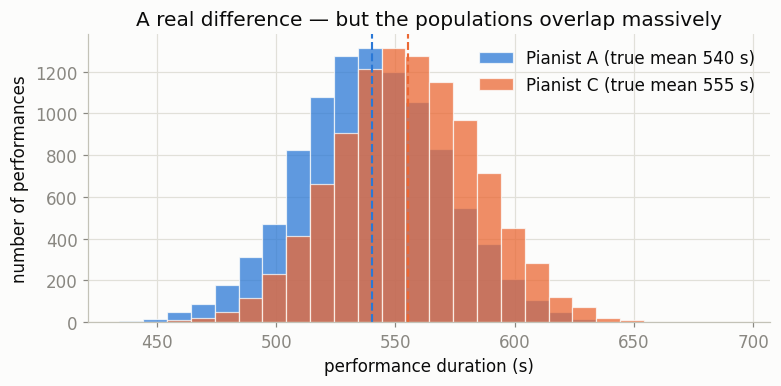

In [36]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, ax = plt.subplots(figsize=(8, 3.4))
lo = min(pianist_A.min(), pianist_C.min())
hi = max(pianist_A.max(), pianist_C.max())
bins = np.arange(lo, hi + 10, 10)

ax.hist(pianist_A, bins=bins, color=BLUE, alpha=0.75, edgecolor=SURFACE,
        linewidth=0.8, label=f"Pianist A (true mean {MEAN_A} s)")
ax.hist(pianist_C, bins=bins, color=ORANGE, alpha=0.75, edgecolor=SURFACE,
        linewidth=0.8, label=f"Pianist C (true mean {MEAN_C} s)")
ax.axvline(pianist_A.mean(), color=BLUE, linewidth=1.4, linestyle="--")
ax.axvline(pianist_C.mean(), color=ORANGE, linewidth=1.4, linestyle="--")

ax.set_xlabel("performance duration (s)")
ax.set_ylabel("number of performances")
ax.set_title("A real difference — but the populations overlap massively")
ax.legend(frameon=False)
plt.show()

The difference is real, but the histograms overlap almost entirely: on plenty of nights,
Pianist C is *faster* than a typical Pianist A performance. What does a small study
see in this world?

In [40]:
# ═══ DATA GENERATION ═══  1,000 studies comparing C with A
diffs_real = np.array([one_study(pianist_C, pianist_A, n) for _ in range(n_studies)])

wrong_direction = np.mean(diffs_real <= 0) * 100
print(f"True difference (C − A): {MEAN_C - MEAN_A:+.1f} s")
print(f"With n = {n} per pianist, across {n_studies:,} studies:")
print(f"  smallest observed difference: {diffs_real.min():+6.1f} s")
print(f"  largest observed difference:  {diffs_real.max():+6.1f} s")
print(f"  studies pointing the WRONG way (A appears slower): {wrong_direction:.0f}%")

True difference (C − A): +15.0 s
With n = 15 per pianist, across 1,000 studies:
  smallest observed difference:  -14.9 s
  largest observed difference:   +50.8 s
  studies pointing the WRONG way (A appears slower): 7%


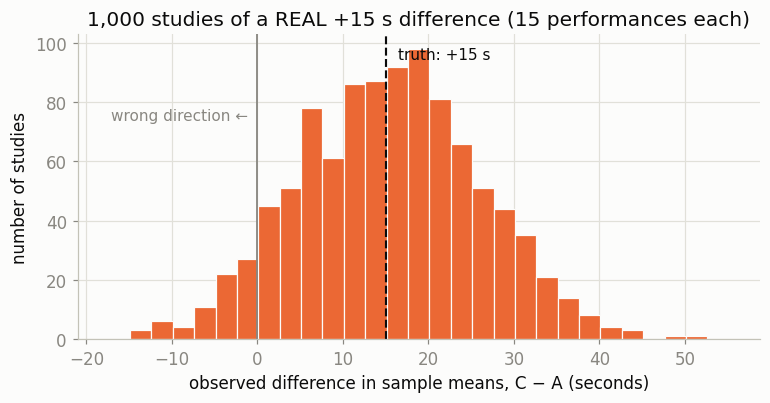

In [41]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, ax = plt.subplots(figsize=(8, 3.6))

true_gap = MEAN_C - MEAN_A
ax.hist(diffs_real, bins=np.arange(diffs_real.min() - 2.5, diffs_real.max() + 5, 2.5),
        color=ORANGE, edgecolor=SURFACE, linewidth=0.8)
ax.axvline(true_gap, color=INK, linewidth=1.4, linestyle="--")
ax.annotate(f"truth: {true_gap:+.0f} s", (true_gap, ax.get_ylim()[1] * 0.92),
            color=INK, fontsize=10, xytext=(8, 0), textcoords="offset points")
ax.axvline(0, color=MUTED, linewidth=1.2)
ax.annotate("wrong direction ←", (0, ax.get_ylim()[1] * 0.72), color=MUTED,
            fontsize=10, ha="right", xytext=(-6, 0), textcoords="offset points")

ax.set_xlabel("observed difference in sample means, C − A (seconds)")
ax.set_ylabel("number of studies")
ax.set_title(f"{n_studies:,} studies of a REAL {true_gap:+.0f} s difference "
             f"({n} performances each)")
plt.show()

Even though Pianist C *really* averages 15 seconds slower, it can happen that a study with 15
performances sometimes measures the difference as +40 seconds, sometimes as
roughly zero — and a non-trivial share of studies point in the **wrong direction**
entirely.

How quickly does a bigger sample fix this?

In [42]:
# ═══ DATA GENERATION ═══  chance of a wrong-way result, at several sample sizes
sizes = np.array([5, 10, 20, 50, 100, 200])   # ← knob: sample sizes to test

p_wrong = []
for size in sizes:
    d = np.array([one_study(pianist_C, pianist_A, size) for _ in range(n_studies)])
    p_wrong.append(np.mean(d <= 0) * 100)

for size, p in zip(sizes, p_wrong):
    print(f"n = {size:3d}:  {p:4.1f}% of studies point the wrong way")

n =   5:  21.7% of studies point the wrong way
n =  10:  11.7% of studies point the wrong way
n =  20:   6.3% of studies point the wrong way
n =  50:   0.4% of studies point the wrong way
n = 100:   0.0% of studies point the wrong way
n = 200:   0.0% of studies point the wrong way


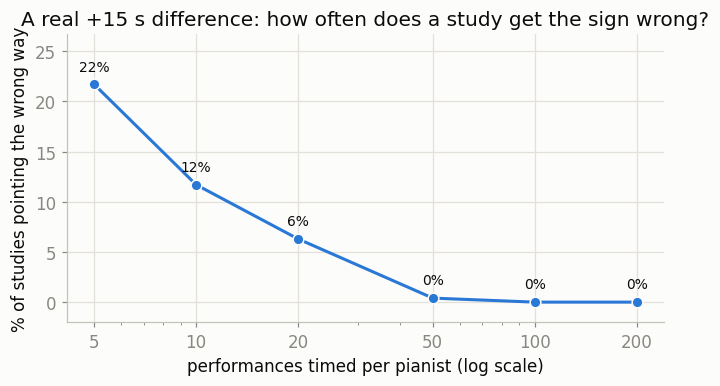

In [43]:
# ═══ PLOTTING ONLY ═══  (nothing here changes the data)
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(sizes, p_wrong, "-o", color=BLUE, linewidth=2, markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=1)
ax.set_ylim(-2, max(p_wrong) + 5)   # headroom for the labels
for x, y in zip(sizes, p_wrong):
    ax.annotate(f"{y:.0f}%", (x, y), xytext=(0, 9),
                textcoords="offset points", ha="center", fontsize=9, color=INK)

ax.set_xscale("log")
ax.set_xticks(sizes, [str(s) for s in sizes])
ax.set_xlabel("performances timed per pianist (log scale)")
ax.set_ylabel("% of studies pointing the wrong way")
ax.set_title(f"A real {MEAN_C - MEAN_A:+.0f} s difference: "
             "how often does a study get the sign wrong?")
plt.show()